In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import place_poles

### 1)



Se parte de las velocidades expresadas en el sistema de referencia del cuerpo:

Velocidad longitudinal constante:

$$
u_0 = 2 \ \text{m/s}
$$

Velocidad lateral:

$$
v(t)
$$

Por lo tanto, el vector de velocidades en el sistema del cuerpo puede escribirse como:

$$
\begin{bmatrix}
u_0 \\
v
\end{bmatrix}
$$

Para expresar estas velocidades en el sistema inercial, en coordenadas (X) e (Y), es necesario transformarlas desde el sistema del cuerpo hacia el sistema inercial mediante una matriz de rotación dependiente del ángulo de rumbo ($\psi$).

La matriz de rotación correspondiente es:

$$
R(\psi)=
\begin{bmatrix}
\cos(\psi) & -\sin(\psi) \\
\sin(\psi) & \cos(\psi)
\end{bmatrix}
$$

Entonces, la relación entre las velocidades en el sistema del cuerpo y las velocidades en el sistema inercial queda dada por:

$$
\begin{bmatrix}
\dot X \\
\dot Y
\end{bmatrix}
=
\begin{bmatrix}
\cos(\psi) & -\sin(\psi) \\
\sin(\psi) & \cos(\psi)
\end{bmatrix}
\begin{bmatrix}
u_0 \\
v
\end{bmatrix}
$$

Resolviendo el producto matricial se obtiene:

$$
\dot X = u_0 \cos(\psi) - v \sin(\psi)
$$

$$
\dot Y = u_0 \sin(\psi) + v \cos(\psi)
$$

### 2)

In [15]:
# Modelo de la Parte A


A = np.array([
    [-0.25, -2.00, 0.00],
    [ 0.08, -0.35, 0.00],
    [ 0.00,  1.00, 0.00]
])

B = np.array([
    [0.00],
    [0.62],
    [0.00]
])

C = np.array([[0.00, 0.00, 1.00]])

Aa = np.block([
    [A, np.zeros((3, 1))],
    [-C, np.zeros((1, 1))]
])

Ba = np.vstack([
    B,
    [[0.00]]
])

Ea = np.array([
    [0.00],
    [0.00],
    [0.00],
    [1.00]
])

polos_deseados = [-1.5, -2.0, -2.5, -3.0]

Ka = place_poles(Aa, Ba, polos_deseados).gain_matrix

print("Ka =", Ka)

Ka = [[-174.51814516   13.5483871  -304.83870968 -145.16129032]]


In [16]:
u0 = 2.0  # velocidad longitudinal constante [m/s]

def psi_ref(t):
    if t < 10:
        return 0.0
    elif t < 25:
        return np.pi / 6
    elif t < 40:
        return -np.pi / 6
    else:
        return np.pi / 3

def dinamica_parteB(t, z):
    v = z[0]
    r = z[1]
    psi = z[2]
    xi = z[3]
    X = z[4]
    Y = z[5]

    xa = np.array([[v], [r], [psi], [xi]])

    # Ley de control de la Parte A
    tau_r = tau_r = (-Ka @ xa).item()

    # Referencia
    ref = psi_ref(t)

    # Dinámica lateral-direccional
    v_dot = -0.25 * v - 2.0 * r
    r_dot = 0.08 * v - 0.35 * r + 0.62 * tau_r
    psi_dot = r

    # Integrador del error
    xi_dot = ref - psi

    # Cinemática en el plano inercial
    X_dot = u0 * np.cos(psi) - v * np.sin(psi)
    Y_dot = u0 * np.sin(psi) + v * np.cos(psi)

    return [v_dot, r_dot, psi_dot, xi_dot, X_dot, Y_dot]

In [17]:
#Estados iniciales: v(0)=0, r(0)=0, psi(0)=0, xi(0)=0, X(0)=0, Y(0)=0
z0 = [0, 0, 0, 0, 0, 0]

Tf = 60
T_sim = np.linspace(0, Tf, 1000)

sol = solve_ivp(dinamica_parteB, [0, Tf], z0, t_eval=T_sim, rtol=1e-8, atol=1e-10)

v = sol.y[0, :]
r = sol.y[1, :]
psi = sol.y[2, :]
xi = sol.y[3, :]
X = sol.y[4, :]
Y = sol.y[5, :]

print("Posición inicial:")
print("X(0) =", X[0])
print("Y(0) =", Y[0])

print("Posición final:")
print("X(Tf) =", X[-1])
print("Y(Tf) =", Y[-1])

Posición inicial:
X(0) = 0.0
Y(0) = 0.0
Posición final:
X(Tf) = 97.41219811567952
Y(Tf) = 38.12414720859261


In [18]:
# from scipy.integrate import cumulative_trapezoid
# import numpy as np

# # Velocidad longitudinal constante
# u0 = 2.0  # [m/s]

# # Estados obtenidos en la simulación de la Parte A
# v = yout[0, :]
# r = yout[1, :]
# psi = yout[2, :]
# xi = yout[3, :]

# # Ecuaciones cinemáticas
# X_dot = u0 * np.cos(psi) - v * np.sin(psi)
# Y_dot = u0 * np.sin(psi) + v * np.cos(psi)

# # Integración numérica con condición inicial X(0)=0, Y(0)=0
# X = cumulative_trapezoid(X_dot, T_sim, initial=0)
# Y = cumulative_trapezoid(Y_dot, T_sim, initial=0)

# print(f"Posición inicial: X(0) = {X[0]:.4f} m, Y(0) = {Y[0]:.4f} m")
# print(f"Posición final: X(Tf) = {X[-1]:.4f} m, Y(Tf) = {Y[-1]:.4f} m")

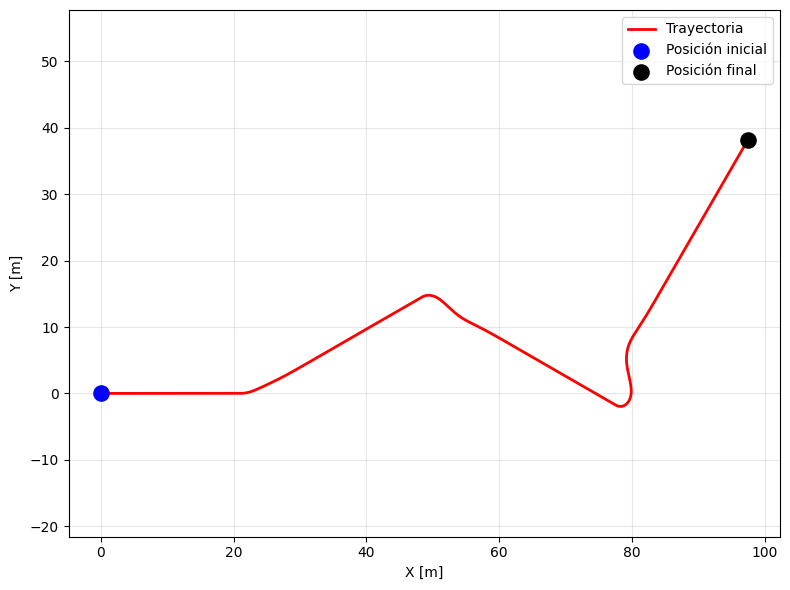

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(X, Y, color='red', linewidth=2, label='Trayectoria')
plt.scatter(X[0], Y[0], color='blue', s=120, label='Posición inicial', zorder=3)
plt.scatter(X[-1], Y[-1], color='black', s=120, label='Posición final', zorder=3)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

### 4) FALTA

Explique c´omo los cambios en la referencia de rumbo ψref afectan la trayectoria recorrida por la
embarcaci´on. En particular, analice qu´e ocurre cuando la referencia cambia entre los siguientes
valores:
ψref = 0 ψref = π/6 ψref = −π/6 ψref = π/3

### 5)  FALTA

* La posibilidad de considerar las variables X e Y como salidas controladas, y c´omo cambiar´ıa el problema de control.
* A partir de los gr´aficos pedidos, si la trayectoria recorrida es consistente con los cambios de rumbo pedidos.
* C´omo afecta la velocidad de respuesta del controlador a la trayectoria.
* C´omo afecta la velocidad lateral v(t) a la posici´on en el plano.
* Si la trayectoria representa cambios suaves o bruscos.
* Qu´e limitaciones tendr´ıa este esquema si se quisiera controlar directamente la posici´on en el plano XY.